Device: cpu

Dataset loaded: (49396, 2)

Training   : 39516
Validation : 4940
Testing    : 4940

Vocabulary size: 10000

Model created successfully!


TRAINING
Epoch 1/3 | Train Loss: 0.6631 | Validation Loss: 0.8898 | Train Accuracy: 59.23% | Validation Accuracy: 56.96%
Epoch 2/3 | Train Loss: 0.7053 | Validation Loss: 0.6925 | Train Accuracy: 50.85% | Validation Accuracy: 51.07%
Epoch 3/3 | Train Loss: 0.6707 | Validation Loss: 0.5881 | Train Accuracy: 57.89% | Validation Accuracy: 71.62%


MODEL PERFORMANCE
Accuracy  : 71.48%
Precision : 68.62%
Recall    : 79.15%
F1-Score  : 73.51%


TRAINING / VALIDATION LOSS
Epoch 1: Training Loss = 0.6631, Validation Loss = 0.8898
Epoch 2: Training Loss = 0.7053, Validation Loss = 0.6925
Epoch 3: Training Loss = 0.6707, Validation Loss = 0.5881


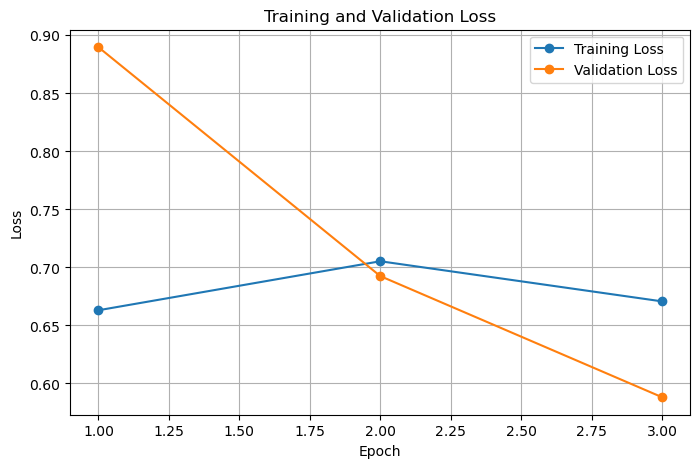



Input: The movie was excellent and very enjoyable.
Predicted Sentiment: Positive
Confidence: 71%


In [2]:
# ============================================================
# IMDb LSTM SENTIMENT ANALYZER - FAST VERSION
# ============================================================

import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_PATH = "IMDB_Dataset_CLEANED.csv"

MAX_VOCAB_SIZE = 10000
MAX_LENGTH = 100

EMBEDDING_DIM = 64
HIDDEN_DIM = 64

BATCH_SIZE = 128
EPOCHS = 3

LEARNING_RATE = 0.001

PAD_IDX = 0
UNK_IDX = 1

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded:", df.shape)


# ============================================================
# 3. CLEAN DATA
# ============================================================

df = df.dropna(
    subset=["review", "sentiment"]
)

df = df.drop_duplicates(
    subset=["review"]
)


def clean_text(text):

    text = str(text).lower()

    # Remove HTML
    text = re.sub(
        r"<br\s*/?>",
        " ",
        text
    )

    # Keep only letters
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


df["cleaned_review"] = df[
    "review"
].apply(clean_text)


# ============================================================
# 4. CONVERT LABELS
# ============================================================

df["label"] = df[
    "sentiment"
].map({
    "negative": 0,
    "positive": 1
})


X = df["cleaned_review"].values
y = df["label"].values


# ============================================================
# 5. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("\nTraining   :", len(X_train))
print("Validation :", len(X_valid))
print("Testing    :", len(X_test))


# ============================================================
# 6. BUILD VOCABULARY
# ============================================================

counter = Counter()

for text in X_train:

    counter.update(
        text.split()
    )


vocab = {
    "<PAD>": PAD_IDX,
    "<UNK>": UNK_IDX
}


for i, (word, count) in enumerate(
    counter.most_common(
        MAX_VOCAB_SIZE - 2
    ),
    start=2
):

    vocab[word] = i


print(
    "\nVocabulary size:",
    len(vocab)
)


# ============================================================
# 7. ENCODE REVIEWS
# ============================================================

def encode_text(text):

    words = text.split()

    sequence = [
        vocab.get(
            word,
            UNK_IDX
        )
        for word in words
    ]

    # Truncate
    sequence = sequence[
        :MAX_LENGTH
    ]

    # Padding
    sequence += [
        PAD_IDX
    ] * (
        MAX_LENGTH - len(sequence)
    )

    return sequence


X_train_encoded = np.array([
    encode_text(text)
    for text in X_train
])

X_valid_encoded = np.array([
    encode_text(text)
    for text in X_valid
])

X_test_encoded = np.array([
    encode_text(text)
    for text in X_test
])


# ============================================================
# 8. PYTORCH DATASET
# ============================================================

class IMDbDataset(Dataset):

    def __init__(
        self,
        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.long
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(
        self,
        index
    ):

        return (
            self.X[index],
            self.y[index]
        )


train_dataset = IMDbDataset(
    X_train_encoded,
    y_train
)

valid_dataset = IMDbDataset(
    X_valid_encoded,
    y_valid
)

test_dataset = IMDbDataset(
    X_test_encoded,
    y_test
)


# ============================================================
# 9. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 10. LSTM MODEL
# ============================================================

class SentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size
    ):

        super().__init__()

        # Embedding
        self.embedding = nn.Embedding(
            vocab_size,
            EMBEDDING_DIM,
            padding_idx=PAD_IDX
        )

        # LSTM
        self.lstm = nn.LSTM(
            EMBEDDING_DIM,
            HIDDEN_DIM,
            batch_first=True
        )

        # Fully connected
        self.fc = nn.Linear(
            HIDDEN_DIM,
            1
        )


    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = (
            self.lstm(embedded)
        )

        # Last hidden state
        hidden = hidden[-1]

        output = self.fc(hidden)

        return output.squeeze(1)


# ============================================================
# 11. CREATE MODEL
# ============================================================

model = SentimentLSTM(
    len(vocab)
).to(DEVICE)


criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


print("\nModel created successfully!")


# ============================================================
# 12. TRAINING FUNCTION
# ============================================================

def train_model():

    model.train()

    total_loss = 0

    predictions = []
    actuals = []

    for reviews, labels in train_loader:

        reviews = reviews.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(
            reviews
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        probabilities = torch.sigmoid(
            outputs
        )

        predicted = (
            probabilities >= 0.5
        ).long()

        predictions.extend(
            predicted.cpu().numpy()
        )

        actuals.extend(
            labels.cpu().numpy()
        )

    loss = (
        total_loss /
        len(train_loader)
    )

    accuracy = accuracy_score(
        actuals,
        predictions
    )

    return loss, accuracy


# ============================================================
# 13. VALIDATION FUNCTION
# ============================================================

def validate_model():

    model.eval()

    total_loss = 0

    predictions = []
    actuals = []

    with torch.no_grad():

        for reviews, labels in valid_loader:

            reviews = reviews.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(
                reviews
            )

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            probabilities = torch.sigmoid(
                outputs
            )

            predicted = (
                probabilities >= 0.5
            ).long()

            predictions.extend(
                predicted.cpu().numpy()
            )

            actuals.extend(
                labels.cpu().numpy()
            )

    loss = (
        total_loss /
        len(valid_loader)
    )

    accuracy = accuracy_score(
        actuals,
        predictions
    )

    return loss, accuracy


# ============================================================
# 14. TRAIN
# ============================================================

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []


print("\n")
print("=" * 60)
print("TRAINING")
print("=" * 60)


for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_model()
    )

    valid_loss, valid_accuracy = (
        validate_model()
    )

    train_losses.append(
        train_loss
    )

    validation_losses.append(
        valid_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    validation_accuracies.append(
        valid_accuracy
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {valid_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}% | "
        f"Validation Accuracy: {valid_accuracy * 100:.2f}%"
    )


# ============================================================
# 15. TEST MODEL
# ============================================================

model.eval()

predictions = []
actuals = []


with torch.no_grad():

    for reviews, labels in test_loader:

        reviews = reviews.to(DEVICE)

        outputs = model(
            reviews
        )

        probabilities = torch.sigmoid(
            outputs
        )

        predicted = (
            probabilities >= 0.5
        ).long()

        predictions.extend(
            predicted.cpu().numpy()
        )

        actuals.extend(
            labels.numpy()
        )


# ============================================================
# 16. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    actuals,
    predictions
)

precision = precision_score(
    actuals,
    predictions,
    zero_division=0
)

recall = recall_score(
    actuals,
    predictions,
    zero_division=0
)

f1 = f1_score(
    actuals,
    predictions,
    zero_division=0
)


# ============================================================
# 17. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n")
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1-Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 18. TRAINING / VALIDATION LOSS
# ============================================================

print("\n")
print("=" * 60)
print("TRAINING / VALIDATION LOSS")
print("=" * 60)

for i in range(EPOCHS):

    print(
        f"Epoch {i + 1}: "
        f"Training Loss = "
        f"{train_losses[i]:.4f}, "
        f"Validation Loss = "
        f"{validation_losses[i]:.4f}"
    )


# ============================================================
# 19. LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 20. PREDICTION FUNCTION
# ============================================================

def predict_sentiment(review):

    model.eval()

    cleaned = clean_text(
        review
    )

    sequence = encode_text(
        cleaned
    )

    tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(DEVICE)

    with torch.no_grad():

        output = model(
            tensor
        )

        probability = torch.sigmoid(
            output
        ).item()


    if probability >= 0.5:

        sentiment = "Positive"

        confidence = (
            probability * 100
        )

    else:

        sentiment = "Negative"

        confidence = (
            (1 - probability) * 100
        )


    print("\n")
    print("=" * 60)

    print(
        "Input:",
        review
    )

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        f"Confidence: "
        f"{confidence:.0f}%"
    )

    print("=" * 60)


# ============================================================
# 21. REQUIRED INPUT
# ============================================================

predict_sentiment(
    "The movie was excellent and very enjoyable."
)